#### Name: Md Rasel Hossain
#### Email: raseltarunno82@gmail.com

# Electricity Demand Forecasting using Machine Learning

This project follows the same workflow style as my movie/video-game sales prediction project, but it is more relevant for energy and industrial machine learning roles. The goal is to predict **actual electricity demand** in Spain using market, generation, and time-based features.

## Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

df = pd.read_csv('/content/spain_energy_market.csv')
df.head(10)

,datetime,id,name,geoid,geoname,value
0,2014-01-01 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,25.280833
1,2014-01-02 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,39.924167
2,2014-01-03 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,4.992083
3,2014-01-04 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,4.091667
4,2014-01-05 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,13.587500
5,2014-01-06 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,47.885417
6,2014-01-07 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,41.207500
7,2014-01-08 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,49.022083
8,2014-01-09 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,56.202917
9,2014-01-10 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,50.277083


In [2]:
df.shape

(40212, 6)

In [3]:
# Check missing values
df.isnull().sum()

,0
datetime,0
id,0
name,5478
geoid,29256
geoname,29256
value,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   datetime  40212 non-null  object 
 1   id        40212 non-null  int64  
 2   name      34734 non-null  object 
 3   geoid     10956 non-null  float64
 4   geoname   10956 non-null  object 
 5   value     40212 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 1.8+ MB


### Data Preprocessing

In [5]:
# Convert datetime column to datetime format
df['datetime'] = pd.to_datetime(df['datetime'])

# Drop rows where the measurement name is missing
df = df.dropna(subset=['name']).copy()

# Drop columns that are not useful for modelling
df = df.drop(columns=['id', 'geoid', 'geoname'], errors='ignore')

# Check available time-series variables
df['name'].value_counts()

,count
name,
Precio mercado SPOT Diario ESP,1826
Precio mercado SPOT Diario FRA,1826
Precio mercado SPOT Diario POR,1826
Energía asignada en Mercado SPOT Diario España,1826
Energía asignada en Mercado SPOT Diario Francia,1826
Generación programada PBF Gas Natural Cogeneración,1826
Generación programada PBF Solar fotovoltaica,1826
Generación programada PBF UGH + no UGH,1826
Generación programada PBF Eólica,1825


In [6]:
# Convert the long-format data into wide-format data
energy_df = df.pivot_table(
    index='datetime',
    columns='name',
    values='value',
    aggfunc='mean'
).reset_index()

energy_df.head()

name,datetime,Demanda programada PBF total,Demanda real,Energía asignada en Mercado SPOT Diario España,Energía asignada en Mercado SPOT Diario Francia,Generación programada PBF Carbón,Generación programada PBF Ciclo combinado,Generación programada PBF Eólica,Generación programada PBF Gas Natural Cogeneración,Generación programada PBF Nuclear,...,Generación programada PBF Turbinación bombeo,Generación programada PBF UGH + no UGH,Generación programada PBF total,Precio mercado SPOT Diario ESP,Precio mercado SPOT Diario FRA,Precio mercado SPOT Diario POR,Rentas de congestión mecanismos implícitos diario Francia exportación,Rentas de congestión mecanismos implícitos diario Francia importación,Rentas de congestión mecanismos implícitos diario Portugal exportación,Rentas de congestión mecanismos implícitos diario Portugal importación
0,2014-01-01 23:00:00,620107.7,28191.597222,566081.9,171917.3,2498.7,4497.5,277443.9,75993.1,144654.6,...,15226.2,87564.8,642771.8,25.280833,28.71125,25.043750,NaN,NaN,NaN,10811.0
1,2014-01-02 23:00:00,659865.2,28465.180556,586355.6,164386.5,19741.4,14541.1,237323.1,83437.4,146177.8,...,21979.8,94432.6,658078.5,39.924167,28.39750,38.980417,NaN,NaN,NaN,43035.0
2,2014-01-03 23:00:00,632536.8,26860.493056,609612.9,166611.2,1288.0,3555.6,329506.6,65023.9,145055.3,...,3192.2,92236.2,680564.6,4.992083,12.99750,4.683750,NaN,NaN,NaN,14060.0
3,2014-01-04 23:00:00,610251.7,25333.597222,605090.0,156271.4,NaN,2310.2,292138.3,64036.6,145200.2,...,4540.8,94189.3,644494.7,4.091667,23.08500,4.091667,NaN,NaN,0.0,0.0
4,2014-01-05 23:00:00,572534.1,23905.541667,531020.2,170611.0,2687.0,6297.0,223942.0,74151.3,135624.0,...,5165.4,103851.1,598661.4,13.587500,31.29000,12.762500,NaN,NaN,NaN,37620.0


In [7]:
# Rename important columns into readable English names
rename_cols = {
    'Demanda real': 'Actual_Demand',
    'Demanda programada PBF total': 'Scheduled_Demand',
    'Precio mercado SPOT Diario ESP': 'Spot_Price_Spain',
    'Precio mercado SPOT Diario FRA': 'Spot_Price_France',
    'Precio mercado SPOT Diario POR': 'Spot_Price_Portugal',
    'Generación programada PBF total': 'Total_Generation',
    'Generación programada PBF Eólica': 'Wind_Generation',
    'Generación programada PBF Solar fotovoltaica': 'Solar_Generation',
    'Generación programada PBF Nuclear': 'Nuclear_Generation',
    'Generación programada PBF Carbón': 'Coal_Generation',
    'Generación programada PBF Ciclo combinado': 'Combined_Cycle_Generation',
    'Generación programada PBF Gas Natural Cogeneración': 'Natural_Gas_Cogeneration',
    'Generación programada PBF UGH + no UGH': 'Hydro_Generation',
    'Generación programada PBF Turbinación bombeo': 'Pumped_Hydro_Generation'
}

energy_df = energy_df.rename(columns=rename_cols)
energy_df.columns.name = None
energy_df.head()

,datetime,Scheduled_Demand,Actual_Demand,Energía asignada en Mercado SPOT Diario España,Energía asignada en Mercado SPOT Diario Francia,Coal_Generation,Combined_Cycle_Generation,Wind_Generation,Natural_Gas_Cogeneration,Nuclear_Generation,...,Pumped_Hydro_Generation,Hydro_Generation,Total_Generation,Spot_Price_Spain,Spot_Price_France,Spot_Price_Portugal,Rentas de congestión mecanismos implícitos diario Francia exportación,Rentas de congestión mecanismos implícitos diario Francia importación,Rentas de congestión mecanismos implícitos diario Portugal exportación,Rentas de congestión mecanismos implícitos diario Portugal importación
0,2014-01-01 23:00:00,620107.7,28191.597222,566081.9,171917.3,2498.7,4497.5,277443.9,75993.1,144654.6,...,15226.2,87564.8,642771.8,25.280833,28.71125,25.043750,NaN,NaN,NaN,10811.0
1,2014-01-02 23:00:00,659865.2,28465.180556,586355.6,164386.5,19741.4,14541.1,237323.1,83437.4,146177.8,...,21979.8,94432.6,658078.5,39.924167,28.39750,38.980417,NaN,NaN,NaN,43035.0
2,2014-01-03 23:00:00,632536.8,26860.493056,609612.9,166611.2,1288.0,3555.6,329506.6,65023.9,145055.3,...,3192.2,92236.2,680564.6,4.992083,12.99750,4.683750,NaN,NaN,NaN,14060.0
3,2014-01-04 23:00:00,610251.7,25333.597222,605090.0,156271.4,NaN,2310.2,292138.3,64036.6,145200.2,...,4540.8,94189.3,644494.7,4.091667,23.08500,4.091667,NaN,NaN,0.0,0.0
4,2014-01-05 23:00:00,572534.1,23905.541667,531020.2,170611.0,2687.0,6297.0,223942.0,74151.3,135624.0,...,5165.4,103851.1,598661.4,13.587500,31.29000,12.762500,NaN,NaN,NaN,37620.0


In [8]:
# Check missing values after pivoting
energy_df.isnull().sum().sort_values(ascending=False).head(20)

,0
Rentas de congestión mecanismos implícitos diario Francia exportación,1114
Rentas de congestión mecanismos implícitos diario Portugal exportación,260
Rentas de congestión mecanismos implícitos diario Francia importación,207
Rentas de congestión mecanismos implícitos diario Portugal importación,162
Combined_Cycle_Generation,33
Coal_Generation,3
Pumped_Hydro_Generation,2
Total_Generation,1
Actual_Demand,1
Scheduled_Demand,1


In [9]:
# Sort data by date
energy_df = energy_df.sort_values('datetime').reset_index(drop=True)

# Fill missing values using time-series friendly methods
energy_df = energy_df.ffill().bfill()

# Remove rows where target is missing, just in case
energy_df = energy_df.dropna(subset=['Actual_Demand']).copy()

energy_df.isnull().sum().sum()

np.int64(0)

### Exploratory Data Analysis

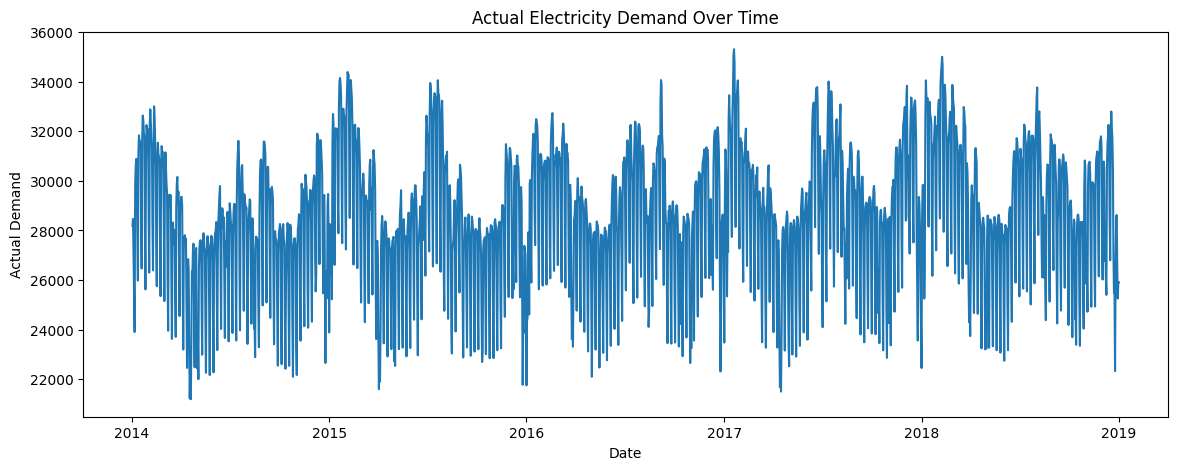

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(energy_df['datetime'], energy_df['Actual_Demand'])
plt.title('Actual Electricity Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Actual Demand')
plt.show()

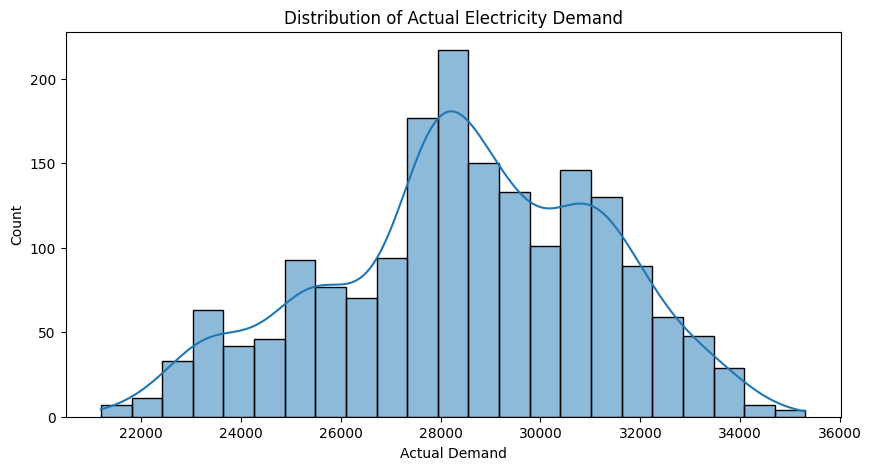

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(energy_df['Actual_Demand'], kde=True)
plt.title('Distribution of Actual Electricity Demand')
plt.xlabel('Actual Demand')
plt.show()

In [13]:
# Correlation with target variable
corr = energy_df.select_dtypes(include=np.number).corr()['Actual_Demand'].sort_values(ascending=False)
corr.head(15)

,Actual_Demand
Actual_Demand,1.000000
Scheduled_Demand,0.967803
Total_Generation,0.827203
Energía asignada en Mercado SPOT Diario España,0.803945
Natural_Gas_Cogeneration,0.525086
Spot_Price_France,0.450247
Coal_Generation,0.377798
Combined_Cycle_Generation,0.371729
Spot_Price_Spain,0.309346
Spot_Price_Portugal,0.296027


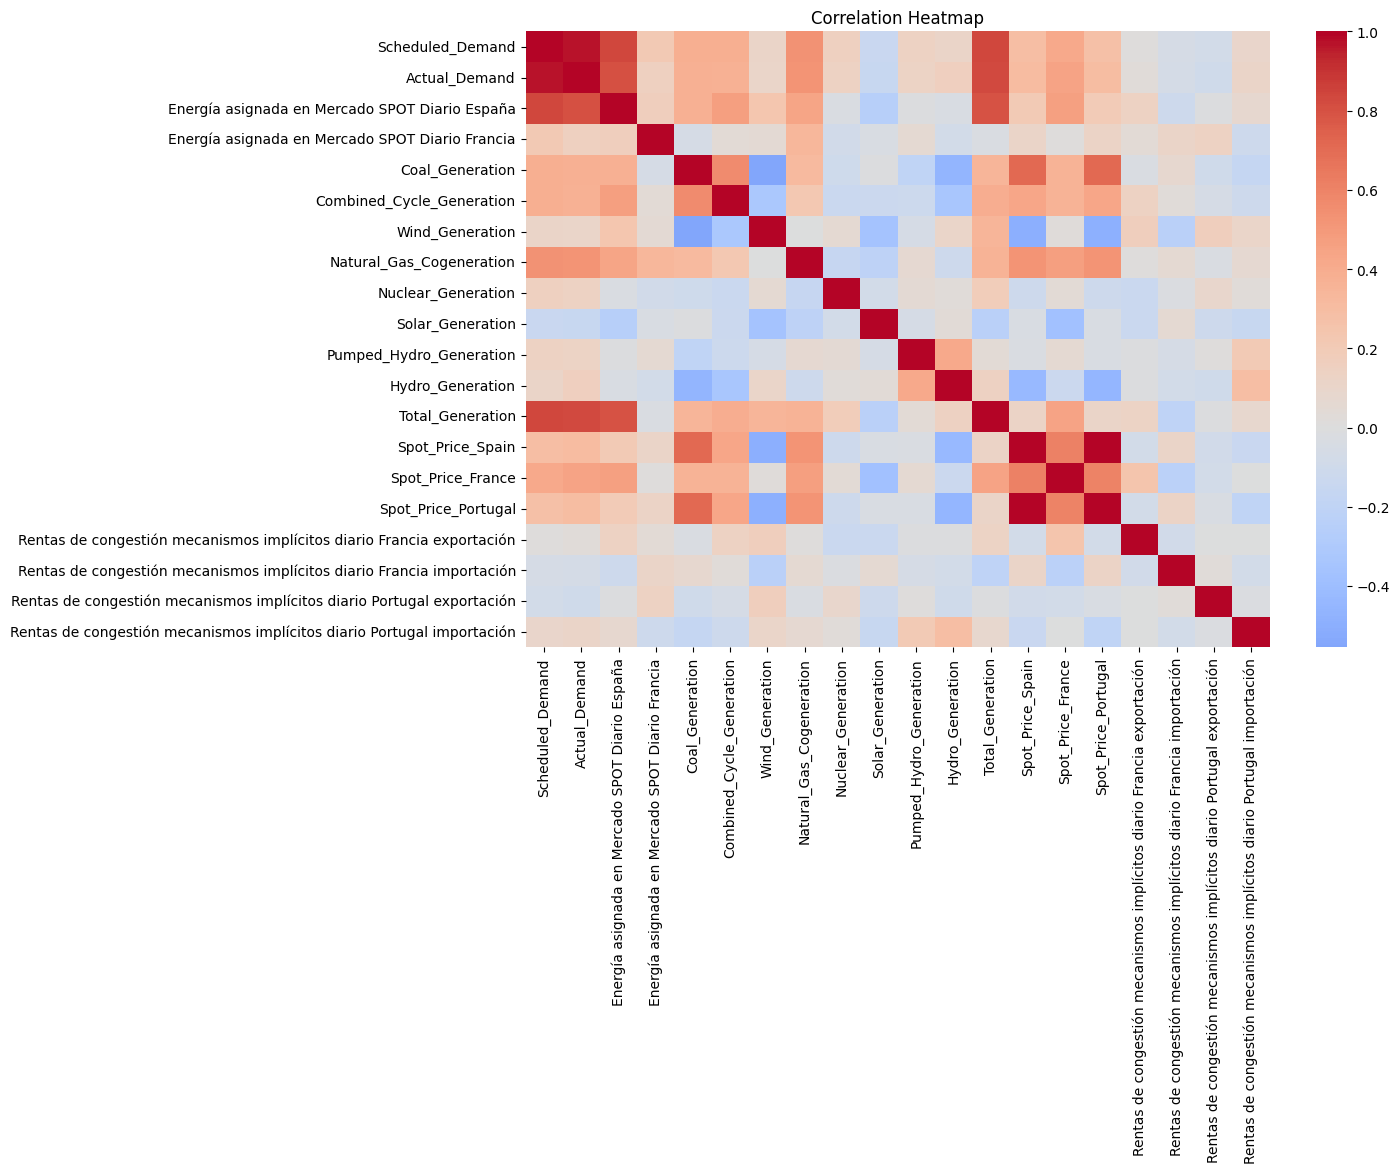

In [14]:
plt.figure(figsize=(12, 8))
sns.heatmap(energy_df.select_dtypes(include=np.number).corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

### Feature Engineering

In [15]:
# Date-based features
energy_df['year'] = energy_df['datetime'].dt.year
energy_df['month'] = energy_df['datetime'].dt.month
energy_df['day'] = energy_df['datetime'].dt.day
energy_df['dayofweek'] = energy_df['datetime'].dt.dayofweek
energy_df['dayofyear'] = energy_df['datetime'].dt.dayofyear
energy_df['quarter'] = energy_df['datetime'].dt.quarter
energy_df['is_weekend'] = energy_df['dayofweek'].isin([5, 6]).astype(int)

# Lag features: previous demand values
energy_df['demand_lag_1'] = energy_df['Actual_Demand'].shift(1)
energy_df['demand_lag_7'] = energy_df['Actual_Demand'].shift(7)
energy_df['demand_lag_14'] = energy_df['Actual_Demand'].shift(14)

# Rolling features
energy_df['demand_rolling_7'] = energy_df['Actual_Demand'].shift(1).rolling(window=7).mean()
energy_df['demand_rolling_14'] = energy_df['Actual_Demand'].shift(1).rolling(window=14).mean()

# Drop rows created by lag/rolling missing values
energy_df = energy_df.dropna().reset_index(drop=True)
energy_df.head()

,datetime,Scheduled_Demand,Actual_Demand,Energía asignada en Mercado SPOT Diario España,Energía asignada en Mercado SPOT Diario Francia,Coal_Generation,Combined_Cycle_Generation,Wind_Generation,Natural_Gas_Cogeneration,Nuclear_Generation,...,day,dayofweek,dayofyear,quarter,is_weekend,demand_lag_1,demand_lag_7,demand_lag_14,demand_rolling_7,demand_rolling_14
0,2014-01-15 23:00:00,720680.9,31591.076389,566133.0,185552.2,22622.7,9070.6,242337.2,87817.0,146649.8,...,15,2,15,1,0,31586.583333,30887.750000,28191.597222,30020.001984,28809.219246
1,2014-01-16 23:00:00,711405.3,31397.673611,543396.4,203582.7,20700.9,9975.6,227000.1,87370.3,146658.0,...,16,3,16,1,0,31591.076389,30847.819444,28465.180556,30120.477183,29052.039187
2,2014-01-17 23:00:00,646256.3,28335.395833,461120.0,181949.1,45943.1,9435.6,140187.5,68857.5,146705.4,...,17,4,17,1,0,31397.673611,27854.055556,26860.493056,30199.027778,29261.502976
3,2014-01-18 23:00:00,617015.7,26466.881944,469428.5,163012.9,2962.6,8980.6,192722.1,68393.8,138156.2,...,18,5,18,1,1,28335.395833,25978.902778,25333.597222,30267.790675,29366.853175
4,2014-01-19 23:00:00,705159.4,31667.131944,575061.6,159789.8,28485.9,8510.6,261296.6,84827.1,145095.5,...,19,6,19,1,1,26466.881944,31149.770833,23905.541667,30337.501984,29447.802083


### Train Test Split

In [16]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor

# Target variable
y = energy_df['Actual_Demand']

# Drop target and datetime from features
X = energy_df.drop(columns=['Actual_Demand', 'datetime'])

# Keep only numeric columns for this project
X = X.select_dtypes(include=np.number)

# Time-based split: first 80% for training, last 20% for testing
split_index = int(len(energy_df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

X_train.shape, X_test.shape

((1449, 31), (363, 31))

### Pipeline Creation

In [17]:
numeric_features = X_train.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ]
)

# Function for model evaluation
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    return mae, rmse, r2, mape, y_pred

### Primary Model Selection

In [18]:
models = {
    'Linear Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor),
        ('model', GradientBoostingRegressor(random_state=42))
    ])
}

results = []
predictions = {}

for name, model in models.items():
    mae, rmse, r2, mape, y_pred = evaluate_model(model, X_train, X_test, y_train, y_test)
    results.append([name, mae, rmse, r2, mape])
    predictions[name] = y_pred

results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'R2 Score', 'MAPE (%)'])
results_df.sort_values(by='RMSE')

,Model,MAE,RMSE,R2 Score,MAPE (%)
1,Random Forest,471.479246,601.821369,0.951198,1.596900
2,Gradient Boosting,559.985770,691.121820,0.935641,1.908937
0,Linear Regression,777.373759,913.820809,0.887482,2.659737


### Model Training

In [19]:
# Voting Regressor
voting_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', VotingRegressor([
        ('rf', RandomForestRegressor(random_state=42)),
        ('gb', GradientBoostingRegressor(random_state=42))
    ]))
])

mae, rmse, r2, mape, voting_pred = evaluate_model(voting_model, X_train, X_test, y_train, y_test)
print('Voting Regressor Results')
print('MAE:', mae)
print('RMSE:', rmse)
print('R2 Score:', r2)
print('MAPE:', mape)

Voting Regressor Results
MAE: 506.30500036492236
RMSE: 632.9609604679648
R2 Score: 0.9460173084606279
MAPE: 1.7194063513018802


In [20]:
# Stacking Regressor
stacking_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', StackingRegressor(
        estimators=[
            ('rf', RandomForestRegressor(random_state=42)),
            ('gb', GradientBoostingRegressor(random_state=42))
        ],
        final_estimator=LinearRegression()
    ))
])

mae, rmse, r2, mape, stacking_pred = evaluate_model(stacking_model, X_train, X_test, y_train, y_test)
print('Stacking Regressor Results')
print('MAE:', mae)
print('RMSE:', rmse)
print('R2 Score:', r2)
print('MAPE:', mape)

Stacking Regressor Results
MAE: 469.5148735088036
RMSE: 589.5515437786054
R2 Score: 0.9531678337210457
MAPE: 1.5993998589366922


### Cross Validation

In [21]:
# TimeSeriesSplit is better than ordinary KFold for forecasting problems
tscv = TimeSeriesSplit(n_splits=5)

cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=tscv, scoring='neg_root_mean_squared_error')
    cv_results.append([name, -scores.mean(), scores.std()])

cv_results_df = pd.DataFrame(cv_results, columns=['Model', 'Mean CV RMSE', 'Std'])
cv_results_df.sort_values(by='Mean CV RMSE')

,Model,Mean CV RMSE,Std
1,Random Forest,684.977796,174.745643
2,Gradient Boosting,712.104461,170.561306
0,Linear Regression,824.272587,366.714900


### Hyperparameter Tuning

In [22]:
# Grid Search for Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print('Best Parameters:', grid_search.best_params_)
print('Best CV RMSE:', -grid_search.best_score_)

Best Parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV RMSE: 682.1308318152061


### Random Search CV

In [23]:
# Randomized Search for Gradient Boosting
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

gb_param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [2, 3, 4, 5],
    'model__subsample': [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    gb_pipeline,
    gb_param_dist,
    n_iter=10,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print('Best Parameters:', random_search.best_params_)
print('Best CV RMSE:', -random_search.best_score_)

Best Parameters: {'model__subsample': 0.8, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.1}
Best CV RMSE: 706.8158680886556


### Best Model Selection

In [24]:
# Compare tuned models on test data
best_models = {
    'Tuned Random Forest': grid_search.best_estimator_,
    'Tuned Gradient Boosting': random_search.best_estimator_
}

final_results = []
final_predictions = {}

for name, model in best_models.items():
    mae, rmse, r2, mape, y_pred = evaluate_model(model, X_train, X_test, y_train, y_test)
    final_results.append([name, mae, rmse, r2, mape])
    final_predictions[name] = y_pred

final_results_df = pd.DataFrame(final_results, columns=['Model', 'MAE', 'RMSE', 'R2 Score', 'MAPE (%)'])
final_results_df.sort_values(by='RMSE')

,Model,MAE,RMSE,R2 Score,MAPE (%)
0,Tuned Random Forest,466.221008,594.594499,0.952363,1.579440
1,Tuned Gradient Boosting,565.842187,698.330541,0.934291,1.930384


In [25]:
# Select best model based on lowest RMSE
best_model_name = final_results_df.sort_values(by='RMSE').iloc[0]['Model']
best_model = best_models[best_model_name]
best_pred = final_predictions[best_model_name]

print('Best Model:', best_model_name)

Best Model: Tuned Random Forest


### Model Performance Evaluation

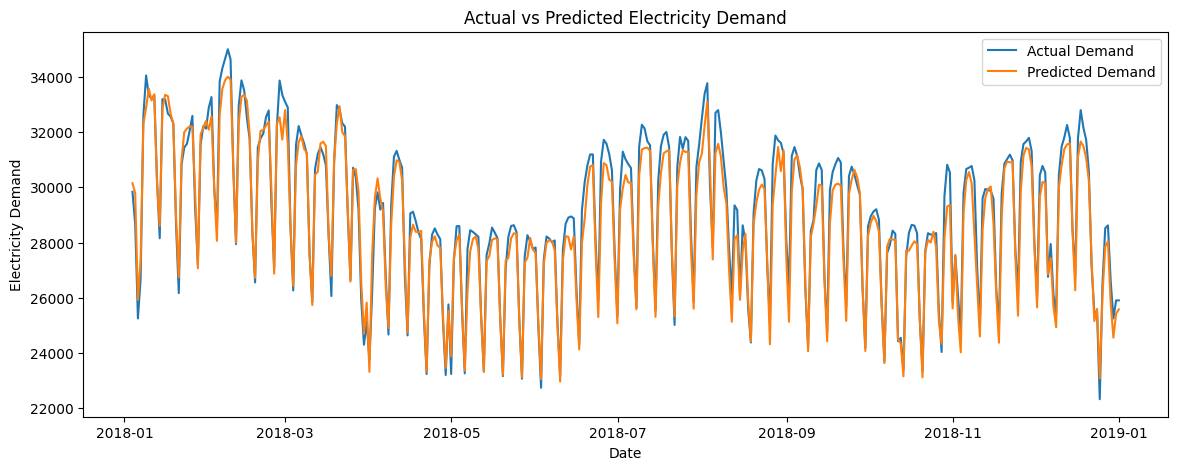

In [26]:
plt.figure(figsize=(14, 5))
plt.plot(energy_df['datetime'].iloc[split_index:], y_test.values, label='Actual Demand')
plt.plot(energy_df['datetime'].iloc[split_index:], best_pred, label='Predicted Demand')
plt.title('Actual vs Predicted Electricity Demand')
plt.xlabel('Date')
plt.ylabel('Electricity Demand')
plt.legend()
plt.show()

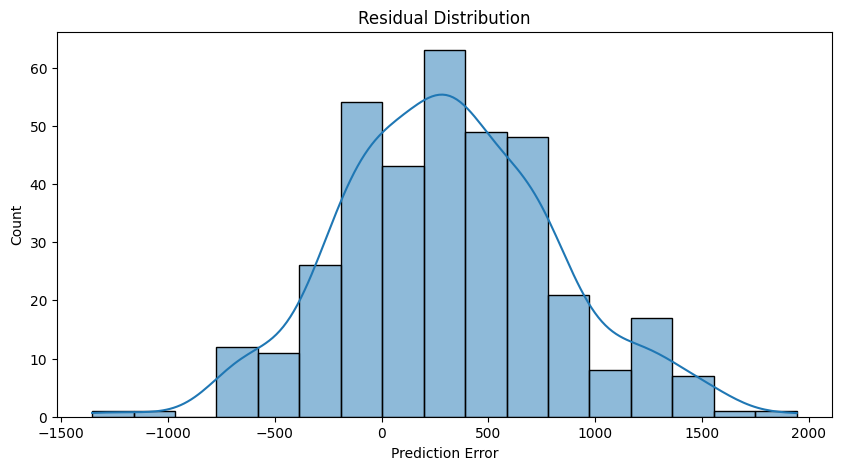

In [27]:
residuals = y_test - best_pred

plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')
plt.xlabel('Prediction Error')
plt.show()

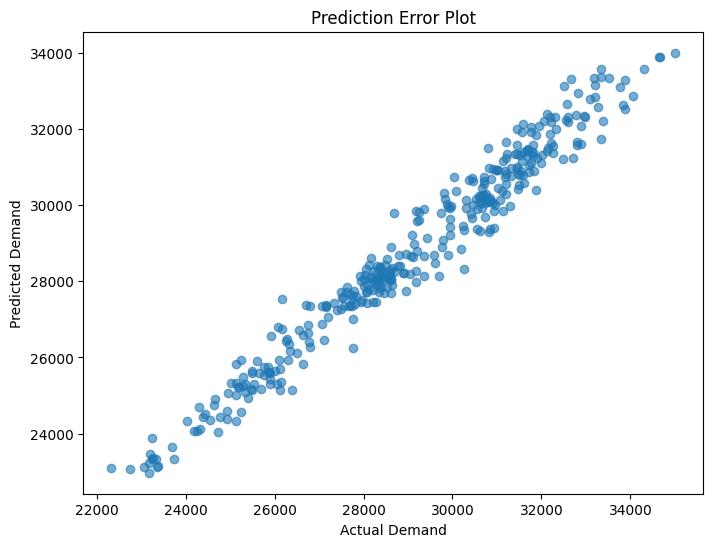

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_pred, alpha=0.6)
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.title('Prediction Error Plot')
plt.show()

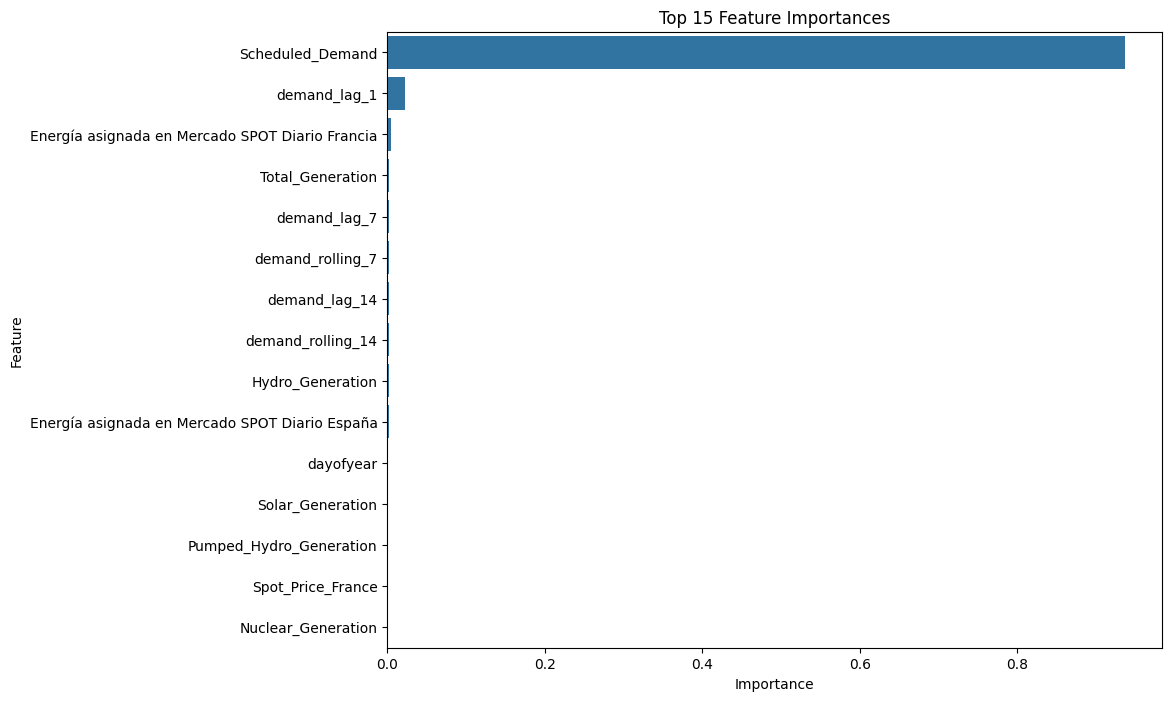

In [29]:
# Feature importance for tree-based models
model_step = best_model.named_steps['model']

if hasattr(model_step, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': model_step.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=importance_df.head(15), x='Importance', y='Feature')
    plt.title('Top 15 Feature Importances')
    plt.show()

    importance_df.head(15)
else:
    print('Feature importance is not directly available for this model.')

### 30-Day Forecasting

In [30]:
# Simple iterative 30-day forecasting based on latest available feature values
# Note: This is a practical demonstration. For production, future exogenous variables should be forecasted separately.

future_dates = pd.date_range(
    start=energy_df['datetime'].max() + pd.Timedelta(days=1),
    periods=30,
    freq='D'
)

last_row = energy_df.iloc[-1:].copy()
future_rows = []
recent_demand_values = energy_df['Actual_Demand'].tolist()

for date in future_dates:
    row = last_row.copy()
    row['datetime'] = date
    row['year'] = date.year
    row['month'] = date.month
    row['day'] = date.day
    row['dayofweek'] = date.dayofweek
    row['dayofyear'] = date.dayofyear
    row['quarter'] = date.quarter
    row['is_weekend'] = int(date.dayofweek in [5, 6])

    row['demand_lag_1'] = recent_demand_values[-1]
    row['demand_lag_7'] = recent_demand_values[-7]
    row['demand_lag_14'] = recent_demand_values[-14]
    row['demand_rolling_7'] = np.mean(recent_demand_values[-7:])
    row['demand_rolling_14'] = np.mean(recent_demand_values[-14:])

    X_future = row[X.columns]
    pred = best_model.predict(X_future)[0]
    row['Predicted_Demand'] = pred
    recent_demand_values.append(pred)
    future_rows.append(row)

future_forecast = pd.concat(future_rows, ignore_index=True)[['datetime', 'Predicted_Demand']]
future_forecast.head()

,datetime,Predicted_Demand
0,2019-01-01 23:00:00,25688.355413
1,2019-01-02 23:00:00,25709.452924
2,2019-01-03 23:00:00,25696.773435
3,2019-01-04 23:00:00,25565.588348
4,2019-01-05 23:00:00,25383.678592


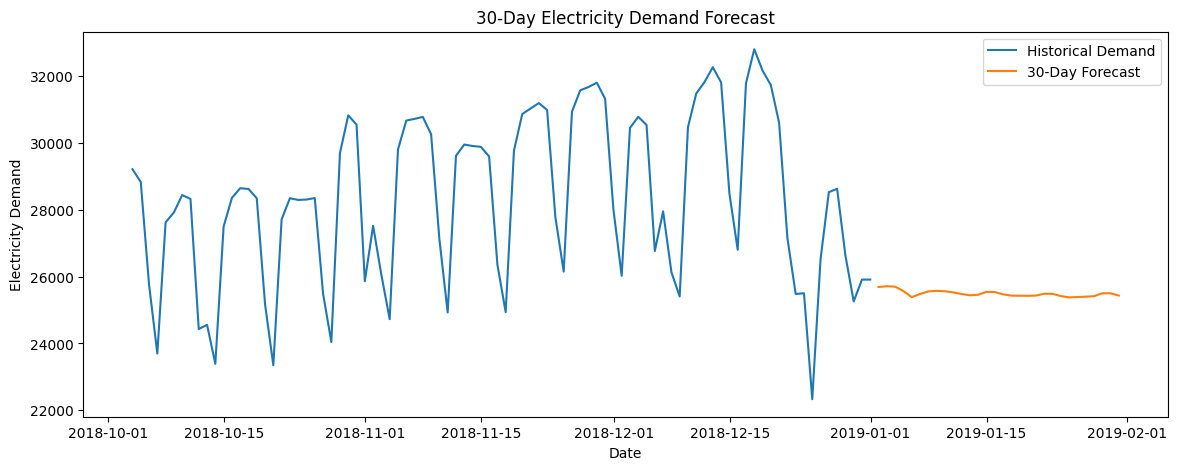

In [31]:
plt.figure(figsize=(14, 5))
plt.plot(energy_df['datetime'].tail(90), energy_df['Actual_Demand'].tail(90), label='Historical Demand')
plt.plot(future_forecast['datetime'], future_forecast['Predicted_Demand'], label='30-Day Forecast')
plt.title('30-Day Electricity Demand Forecast')
plt.xlabel('Date')
plt.ylabel('Electricity Demand')
plt.legend()
plt.show()

### Conclusion

In this project, I built an end-to-end machine learning pipeline for electricity demand forecasting using Spanish electricity market data. I cleaned and reshaped the original long-format dataset, transformed it into a multivariate forecasting dataset, engineered date-based, lag, and rolling-window features, and compared multiple regression models.

The final model was selected based on test RMSE and other evaluation metrics such as MAE, R², and MAPE. This project is relevant for energy and industrial machine learning because accurate demand forecasting can support grid planning, operational decisions, and energy market analysis.

Future improvements could include adding weather data, public holidays, more advanced time-series models, model monitoring, and deployment with Streamlit or Gradio.